Epoch 1/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8204 - loss: 0.5116 - val_accuracy: 0.8494 - val_loss: 0.4074
Epoch 2/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8598 - loss: 0.3811 - val_accuracy: 0.8622 - val_loss: 0.3701
Epoch 3/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8731 - loss: 0.3444 - val_accuracy: 0.8657 - val_loss: 0.3597
Epoch 4/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8825 - loss: 0.3155 - val_accuracy: 0.8786 - val_loss: 0.3330
Epoch 5/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8917 - loss: 0.2946 - val_accuracy: 0.8861 - val_loss: 0.3170
Epoch 6/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8959 - loss: 0.2788 - val_accuracy: 0.8810 - val_loss: 0.3233
Epoch 7/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8995 - loss: 0.2690 - val_accuracy: 0.8874 - val_loss: 0.3149
Epoch 8/50
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9057 - loss: 0.2531 - 

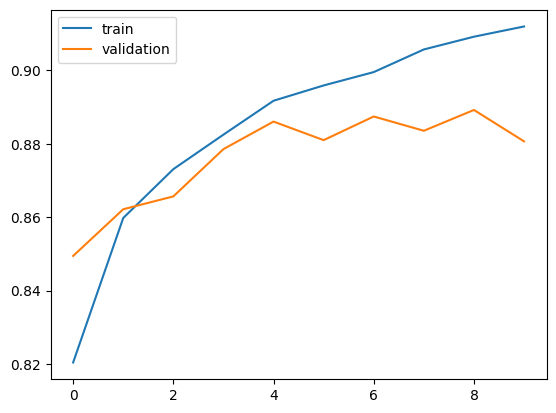

In [2]:
# Practical 6: Early Stopping

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Flatten
from keras.datasets import fashion_mnist
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# 1. Load dataset
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# 2. Normalize data
train_images = train_images / 255.0
test_images = test_images / 255.0

# 3. Split into train + validation
xtrain, xval, ytrain, yval = train_test_split(train_images, train_labels, test_size=0.3)

# 4. Build model
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(300, activation='relu'))
model.add(Dense(10, activation='softmax'))

# 5. Compile model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 6. Apply Early Stopping (IMPORTANT)
callback = tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

# 7. Train model
history = model.fit(xtrain, ytrain,
                    epochs=50,
                    validation_data=(xval, yval),
                    callbacks=[callback])

# 8. Evaluate
model.evaluate(test_images, test_labels)

# 9. Plot accuracy
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.show()